In [1]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [2]:
phi_tr = ScoreNetwork(input_dim=2+1, out_dim=2, hidden_dim=32)
phi_tr.load_state_dict(torch.load('network/tr_phi_network_ip_bsde_nl0.5.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_74300/3535100988.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_tr.load_state_dict(torch.load('network/tr

<All keys matched successfully>

In [3]:
T = 4.0  # End time
n = 2    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 10000 # Number of training samples
dt = 0.05
steps = int(T/dt)
noise_level = 0.5

In [4]:
def f(x, t, ut=None):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    df1 = x[:, 1]
    df2 = torch.sin(x[:, 0]) - 0.01 * x[:, 1]
    df = torch.stack((df1, df2), dim=1)
    return df


def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[0.0], [1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    return 0.5 * x[:,1] * x[:,1] + 1 - torch.cos(x[:,0])

In [5]:
from utils import rollout

iteration    0 | autodiff loss 24729.8 | phi loss 24729.8
iteration  500 | autodiff loss 22957.5 | phi loss 19282.8
iteration 1000 | autodiff loss 21975.4 | phi loss 17454
iteration 1500 | autodiff loss 21221.6 | phi loss 16455.8
iteration 2000 | autodiff loss 20554.4 | phi loss 15637.7
iteration 2500 | autodiff loss 19876.3 | phi loss 15304.9
iteration 3000 | autodiff loss 19364.1 | phi loss 14918.6
iteration 3500 | autodiff loss 19306.8 | phi loss 15000.3
iteration 4000 | autodiff loss 18912.6 | phi loss 15024.7
iteration 4500 | autodiff loss 18640.6 | phi loss 15103.1
iteration 5000 | autodiff loss 18284.4 | phi loss 14833.1
iteration 5500 | autodiff loss 17936.7 | phi loss 14752.1
iteration 6000 | autodiff loss 18130.4 | phi loss 15044.7
iteration 6500 | autodiff loss 17453.3 | phi loss 14663.8
iteration 7000 | autodiff loss 17480.6 | phi loss 14765.7
iteration 7500 | autodiff loss 17373 | phi loss 14835.2
iteration 8000 | autodiff loss 17371.3 | phi loss 14929.7
iteration 8500 | a

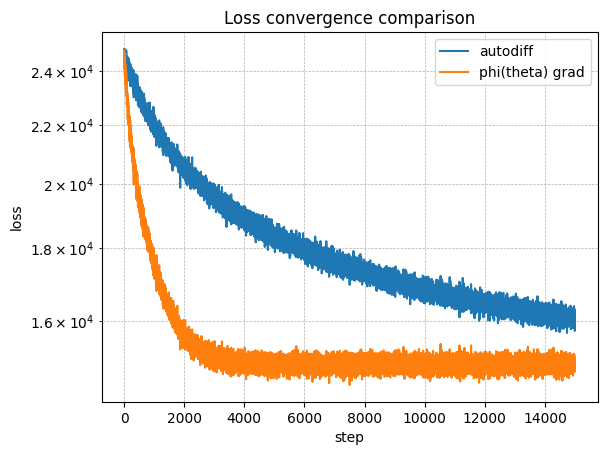

In [6]:
theta0 = torch.randn((N, n))

theta_auto = theta0.clone().detach().requires_grad_(True)
theta_phi  = theta0.clone().detach().requires_grad_(True)  # requires_grad can stay True; we won't call backward()

opt_auto = torch.optim.Adam([theta_auto], lr=1e-3)
opt_phi  = torch.optim.Adam([theta_phi],  lr=1e-3)

loss_hist_auto = []
loss_hist_phi  = []
theta_hist_auto = []
theta_hist_phi  = []
theta_hist_auto.append(theta_auto.detach().clone())
theta_hist_phi.append(theta_phi.detach().clone())
for i in range(15000):
    W_f = torch.randn((steps+1, N, m)) * np.sqrt(dt)
    # ======== Method A: autograd ========
    opt_auto.zero_grad(set_to_none=True)

    
  
    xT_auto = rollout(f, g, T, dt, theta_auto, W_f)[-1]
    loss_auto = lf(xT_auto).sum(dim=0)
    loss_auto.backward()
    opt_auto.step()

    # ======== Method B: custom phi gradient ========
    opt_phi.zero_grad(set_to_none=True)

    # compute loss for logging only (optional but useful)
    # If rollout is expensive and you only care about update, you can skip this forward.
    with torch.no_grad():
        xT_phi = rollout(f, g, T, dt, theta_phi, W_f)[-1]
        loss_phi = lf(xT_phi).sum(dim=0)

    # apply your gradient estimator
    # IMPORTANT: optimizer expects theta_phi.grad to be a tensor on same device/dtype
    with torch.no_grad():
        ghat = phi_tr(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1))  # shape (N, n)
        theta_phi.grad = ghat.detach()
    opt_phi.step()

    # ---- log ----
    loss_hist_auto.append(loss_auto.detach().item() if loss_auto.numel()==1 else loss_auto.detach().sum().item())
    loss_hist_phi.append(loss_phi.detach().item()  if loss_phi.numel()==1  else loss_phi.detach().sum().item())

    theta_hist_auto.append(theta_auto.detach().clone())
    theta_hist_phi.append(theta_phi.detach().clone())

    # optional: print occasionally
    if i % max(1, 500) == 0:
        print(f"iteration {i:4d} | autodiff loss {loss_hist_auto[-1]:.6g} | phi loss {loss_hist_phi[-1]:.6g}")

# ---- final report ----
print("\nFinal:")
print(f"autodiff: loss={loss_hist_auto[-1]:.6g}")
print(f"phi     : loss={loss_hist_phi[-1]:.6g}")

# ---- plot ----
plt.figure()
plt.plot(loss_hist_auto, label="autodiff")
plt.plot(loss_hist_phi,  label="phi(theta) grad")
plt.yscale("log")  # often helpful; remove if you prefer linear
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss convergence comparison")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

Text(0.5, 1.0, 'Optimal theta comparison')

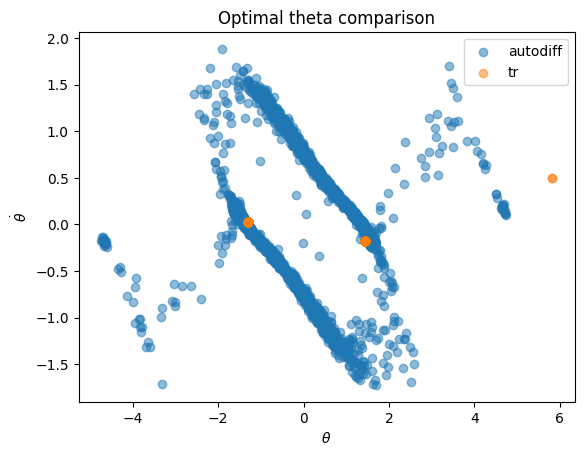

In [7]:
## plot of optimal theta
plt.figure()
plt.scatter(theta_auto.detach().numpy()[:,0], theta_auto.detach().numpy()[:,1], label="autodiff", alpha=0.5)
plt.scatter(theta_phi.detach().numpy()[:,0], theta_phi.detach().numpy()[:,1], label="tr", alpha=0.5)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
plt.legend()
plt.title("Optimal theta comparison")

In [9]:
torch.save(theta_auto, 'data/theta_auto_final.pth')
# torch.save(theta_phi, 'data/theta_tr_final.pth')